In [1]:
import json, glob, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})

OUT = "figures_final"
os.makedirs(OUT, exist_ok=True)

# ---- Verified reference constants ----
BASE_WIN  = 0.65625        # 8 seeds x 500 episodes
BASE_SAP  = 86.0265        # single-agent measure, metrics.py
BASE_CSI  = 0.017541
HUM_SAP   = 17.6758        # 52-episode corpus
HUM_CSI   = -0.35186       # t_norm <= 0.2222 window
RAND_SAP  = 49.8995        # uniform-random policy, d06, 500 episodes
ORACLE    = 1.8809         # corpus-derived DiD ceiling
GATE      = 0.5643         # 30% of oracle
LATE_T    = 0.2222
SAP_DEN   = BASE_SAP - HUM_SAP          # 68.3507

COL  = {"NC":"tab:orange", "C":"tab:green", "SC":"tab:red", "C+KL":"tab:blue"}
CONDS = ["NC","C","SC","C+KL"]

print(f"SAP gap denominator = {SAP_DEN:.4f}")

SAP gap denominator = 68.3507


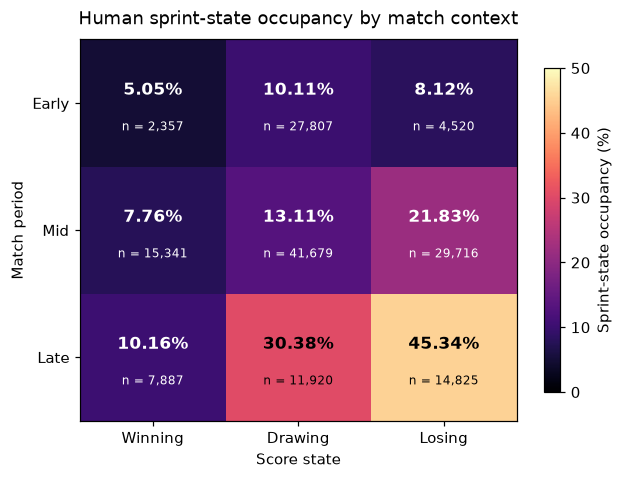

CSI_SAP = -0.3518  expected -0.35186


In [2]:
SAP_GRID = np.array([[ 5.05, 10.11,  8.12],
                     [ 7.76, 13.11, 21.83],
                     [10.16, 30.38, 45.34]])
N_GRID   = np.array([[ 2357, 27807,  4520],
                     [15341, 41679, 29716],
                     [ 7887, 11920, 14825]])

fig, ax = plt.subplots(figsize=(6.4, 4.5))
im = ax.imshow(SAP_GRID, cmap="magma", vmin=0, vmax=50, aspect="auto")
ax.set_xticks(range(3), ["Winning", "Drawing", "Losing"])
ax.set_yticks(range(3), ["Early", "Mid", "Late"])

for i in range(3):
    for j in range(3):
        c = "white" if SAP_GRID[i, j] < 30 else "black"
        ax.text(j, i - 0.10, f"{SAP_GRID[i,j]:.2f}%", ha="center", va="center",
                color=c, fontweight="bold", fontsize=11)
        ax.text(j, i + 0.19, f"n = {N_GRID[i,j]:,}", ha="center", va="center",
                color=c, fontsize=8)

for s in ax.spines.values():
    s.set_visible(True)

fig.colorbar(im, ax=ax, label="Sprint-state occupancy (%)", shrink=0.85)
ax.set_xlabel("Score state"); ax.set_ylabel("Match period")
ax.set_title("Human sprint-state occupancy by match context", pad=10)
fig.savefig(f"{OUT}/fig_4_01_human_context_grid.png")
plt.show()

print("CSI_SAP =", round((SAP_GRID[2,0] - SAP_GRID[2,2]) / 100, 5), " expected -0.35186")

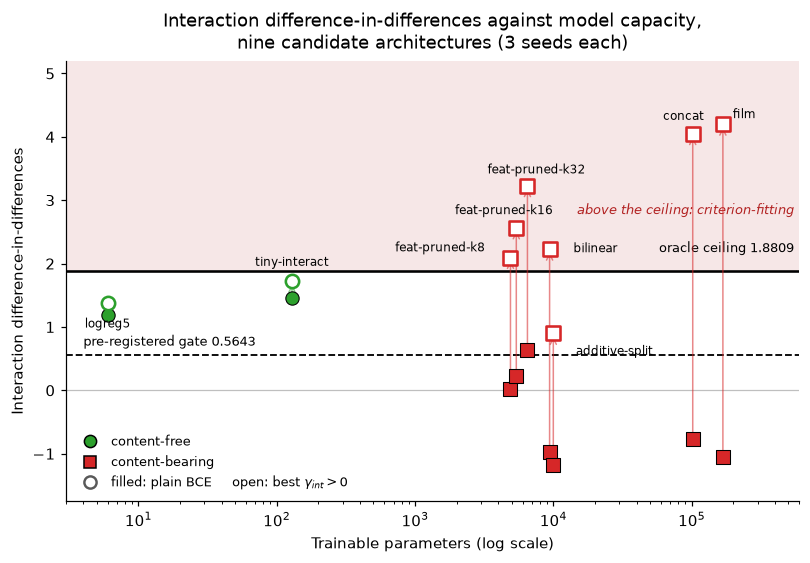

content-bearing above ceiling: 6 of 7 -> ['feat-pruned-k8', 'feat-pruned-k16', 'feat-pruned-k32', 'bilinear', 'concat', 'film']


In [3]:
# name, params, DiD at gamma_int=0, best DiD at gamma_int>0, content-free?, label offset
CANDIDATES = [
    ("logreg5",         6,      1.193,  1.376, True,  (  0, -16)),
    ("tiny-interact",   129,    1.455,  1.723, True,  (  0,  10)),
    ("feat-pruned-k8",  4900,   0.029,  2.096, False, (-46,   4)),
    ("feat-pruned-k16", 5400,   0.224,  2.563, False, ( -8,   9)),
    ("feat-pruned-k32", 6500,   0.635,  3.229, False, (  6,   8)),
    ("bilinear",        9400,  -0.966,  2.227, False, ( 30,  -2)),
    ("additive-split",  10000, -1.179,  0.897, False, ( 40, -14)),
    ("concat",          101889,-0.767,  4.050, False, ( -6,   9)),
    ("film",            168321,-1.052,  4.199, False, ( 14,   4)),
]

fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.axhspan(ORACLE, 5.2, color="#f6e7e7", zorder=0)
ax.axhline(ORACLE, color="k", lw=1.7, zorder=3)
ax.axhline(GATE,   color="k", lw=1.2, ls="--", zorder=3)
ax.axhline(0,      color="0.75", lw=0.8, zorder=1)

for name, p, d0, dg, free, off in CANDIDATES:
    m, c = ("o", "tab:green") if free else ("s", "tab:red")
    ax.annotate("", xy=(p, dg), xytext=(p, d0),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.0, alpha=0.55), zorder=4)
    ax.scatter(p, d0, marker=m, s=76, facecolor=c,      edgecolor="k", lw=0.7, zorder=6)
    ax.scatter(p, dg, marker=m, s=76, facecolor="white", edgecolor=c,  lw=1.7, zorder=6)
    ax.annotate(name, (p, dg), textcoords="offset points", xytext=off,
                fontsize=7.8, ha="center", zorder=7)

ax.set_xscale("log"); ax.set_xlim(3, 6e5); ax.set_ylim(-1.75, 5.2)
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_ylabel("Interaction difference-in-differences")
ax.text(5.5e5, ORACLE + 0.30, f"oracle ceiling {ORACLE}", fontsize=8.6, ha="right")
ax.text(5.5e5, ORACLE + 0.90, "above the ceiling: criterion-fitting",
        fontsize=8.6, ha="right", color="firebrick", style="italic")
ax.text(4.0, GATE + 0.14, f"pre-registered gate {GATE}", fontsize=8.6, ha="left")

ax.legend(handles=[
    Line2D([], [], marker="o", ls="", mfc="tab:green", mec="k", ms=8, label="content-free"),
    Line2D([], [], marker="s", ls="", mfc="tab:red",   mec="k", ms=8, label="content-bearing"),
    Line2D([], [], marker="o", ls="", mfc="white", mec="0.35", mew=1.6, ms=8,
           label=r"filled: plain BCE     open: best $\gamma_{int}>0$"),
], loc="lower left", fontsize=8.4, frameon=False, handletextpad=0.6)

ax.set_title("Interaction difference-in-differences against model capacity,\n"
             "nine candidate architectures (3 seeds each)", pad=8)
fig.savefig(f"{OUT}/fig_4_02_oracle_ceiling.png")
plt.show()

above = [n for n, p, d0, dg, f, o in CANDIDATES if (not f) and dg > ORACLE]
print(f"content-bearing above ceiling: {len(above)} of 7 -> {above}")

using verified literals: [Errno 2] No such file or directory: 'condition_summary.json'


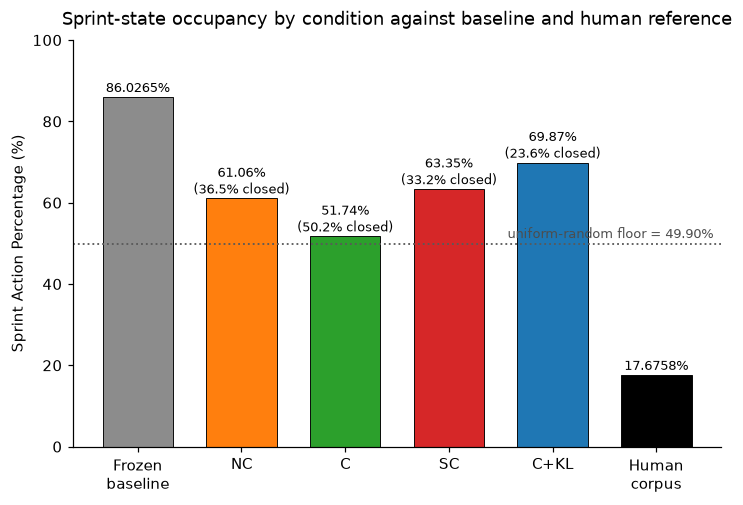

  NC    61.0596  ->   36.5% closed
  C     51.7354  ->   50.2% closed
  SC    63.3525  ->   33.2% closed
  C+KL  69.8732  ->   23.6% closed


In [4]:
# Reads condition_summary.json if present; otherwise uses the verified values.
try:
    cs = {d["condition"]: d for d in json.load(open("condition_summary.json"))}
    SAP = {k: cs[k]["sap_mean"]["mean"] for k in CONDS}
    print("loaded from condition_summary.json")
except Exception as e:
    SAP = {"NC": 61.0596, "C": 51.7354, "SC": 63.3525, "C+KL": 69.8732}
    print("using verified literals:", e)

labels = ["Frozen\nbaseline"] + CONDS + ["Human\ncorpus"]
values = [BASE_SAP] + [SAP[k] for k in CONDS] + [HUM_SAP]
colors = ["0.55"] + [COL[k] for k in CONDS] + ["black"]

fig, ax = plt.subplots(figsize=(7.6, 4.8))
bars = ax.bar(labels, values, color=colors, edgecolor="k", lw=0.6, width=0.68)
ax.axhline(RAND_SAP, color="0.35", ls=":", lw=1.2)
ax.text(len(labels) - 0.45, RAND_SAP + 1.4,
        f"uniform-random floor = {RAND_SAP:.2f}%", ha="right", fontsize=8.5, color="0.3")

for r, k in zip(bars[1:5], CONDS):
    ax.text(r.get_x() + r.get_width()/2, r.get_height() + 1.2,
            f"{SAP[k]:.2f}%\n({100*(BASE_SAP-SAP[k])/SAP_DEN:.1f}% closed)",
            ha="center", fontsize=8.5)
ax.text(bars[0].get_x()+bars[0].get_width()/2, BASE_SAP+1.2, f"{BASE_SAP:.4f}%",
        ha="center", fontsize=8.5)
ax.text(bars[-1].get_x()+bars[-1].get_width()/2, HUM_SAP+1.2, f"{HUM_SAP:.4f}%",
        ha="center", fontsize=8.5)

ax.set_ylabel("Sprint Action Percentage (%)"); ax.set_ylim(0, 100)
ax.set_title("Sprint-state occupancy by condition against baseline and human reference", pad=10)
fig.savefig(f"{OUT}/fig_4_03_gap_closure.png")
plt.show()

for k in CONDS:
    print(f"  {k:5s} {SAP[k]:7.4f}  ->  {100*(BASE_SAP-SAP[k])/SAP_DEN:5.1f}% closed")

In [5]:
# --- ADJUST GLOB PATTERNS TO MATCH YOUR NAMING ---
ROLLOUT_GLOB = "results_v2/rollouts/**/*.npz"   
EXPERT_GLOB  = "data/demonstrations/episodes/*.npz"  

for tag, pattern in [("ROLLOUT", ROLLOUT_GLOB), ("EXPERT", EXPERT_GLOB)]:
    files = sorted(glob.glob(pattern, recursive=True))
    print(f"\n=== {tag}: {len(files)} files matched by {pattern!r}")
    if not files:
        print("   NO MATCH - fix the pattern"); continue
    print("   first:", files[0])
    with np.load(files[0], allow_pickle=True) as z:
        for k in z.files:
            a = z[k]
            print(f"   {k:24s} shape={getattr(a,'shape',None)} dtype={getattr(a,'dtype',None)}")


=== ROLLOUT: 0 files matched by 'results_v2/rollouts/**/*.npz'
   NO MATCH - fix the pattern

=== EXPERT: 0 files matched by 'data/demonstrations/episodes/*.npz'
   NO MATCH - fix the pattern


In [6]:
# --- ADJUST TO MATCH THE OUTPUT FROM BLOCK 4 ---
F_STICKY = "sticky_actions"   # e.g., expects (T, >=9) or (T, n_agents, >=9)
F_STEPS  = "steps_left"       
F_SL     = "score_left"
F_SR     = "score_right"

SPRINT_IDX = 8
EP_LEN     = 3001
N_MIN      = 90

def _sprint(z):
    a = np.asarray(z[F_STICKY])
    # Confirm this indexes the correct agent dimension for your evaluator setup
    if a.ndim == 3:            
        a = a[:, 0, :]
    return (a[:, SPRINT_IDX] == 1).astype(float)

def _context(z):
    t = np.asarray(z[F_STEPS]).astype(float) / EP_LEN
    d = np.asarray(z[F_SL]).astype(int) - np.asarray(z[F_SR]).astype(int)
    return t, d

def per_minute_sap(files):
    tot = np.zeros(N_MIN); cnt = np.zeros(N_MIN)
    for f in files:
        with np.load(f, allow_pickle=True) as z:
            s = _sprint(z); t, _ = _context(z)
            mins = np.clip(((1.0 - t) * N_MIN).astype(int), 0, N_MIN - 1)
            np.add.at(tot, mins, s); np.add.at(cnt, mins, 1.0)
    return 100.0 * np.divide(tot, cnt, out=np.full(N_MIN, np.nan), where=cnt > 0)

def sustain_grid(files):
    """P(sprint_{t+1}=1 | sprint_t=1) per 3x3 (period x score) cell."""
    num = np.zeros((3, 3)); den = np.zeros((3, 3))
    for f in files:
        with np.load(f, allow_pickle=True) as z:
            s = _sprint(z); t, d = _context(z)
            per = np.where(t > 0.6667, 0, np.where(t > LATE_T, 1, 2))   # early/mid/late
            sco = np.where(d > 0, 0, np.where(d == 0, 1, 2))            # win/draw/loss
            on = s[:-1] == 1
            num[per[:-1][on], sco[:-1][on]] += s[1:][on]
            den[per[:-1][on], sco[:-1][on]] += 1
    return np.divide(num, den, out=np.full((3, 3), np.nan), where=den > 0)

rollouts = {c: sorted(glob.glob(ROLLOUT_GLOB, recursive=True)) for c in CONDS}
for c in CONDS:                       
    # --- ADJUST CONDITION FILTERING STRINGS IF NEEDED ---
    rollouts[c] = [f for f in rollouts[c] if f"-{c}-" in f or f"_{c}_" in f or f"/{c}/" in f]
    print(f"{c:5s}: {len(rollouts[c])} rollout files")

expert_files = sorted(glob.glob(EXPERT_GLOB))
print("expert:", len(expert_files), "files")

NC   : 0 rollout files
C    : 0 rollout files
SC   : 0 rollout files
C+KL : 0 rollout files
expert: 0 files


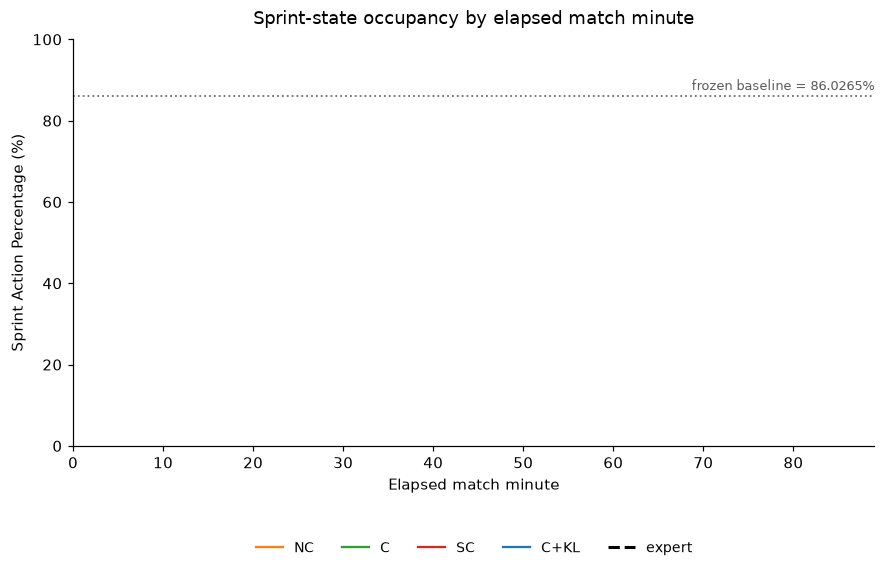

expert first 5 min mean : nan%
expert last 10 min mean : nan%
  NC    range nan - nan%
  C     range nan - nan%
  SC    range nan - nan%
  C+KL  range nan - nan%


C:\Users\u5749464\AppData\Local\Temp\ipykernel_20796\1086044148.py:19: RuntimeWarning: Mean of empty slice
  print(f"expert first 5 min mean : {np.nanmean(sap_exp[:5]):.2f}%")
C:\Users\u5749464\AppData\Local\Temp\ipykernel_20796\1086044148.py:20: RuntimeWarning: Mean of empty slice
  print(f"expert last 10 min mean : {np.nanmean(sap_exp[-10:]):.2f}%")
C:\Users\u5749464\AppData\Local\Temp\ipykernel_20796\1086044148.py:22: RuntimeWarning: All-NaN slice encountered
  print(f"  {c:5s} range {np.nanmin(sap_min[c]):.1f} - {np.nanmax(sap_min[c]):.1f}%")


In [7]:
sap_min = {c: per_minute_sap(rollouts[c]) for c in CONDS}
sap_exp = per_minute_sap(expert_files)

fig, ax = plt.subplots(figsize=(9.4, 4.8))
for c in CONDS:
    ax.plot(np.arange(N_MIN), sap_min[c], color=COL[c], lw=1.5, label=c)

ax.plot(np.arange(N_MIN), sap_exp, color="k", lw=2.0, ls="--", label="expert")
ax.axhline(BASE_SAP, color="0.45", lw=1.2, ls=":")
ax.text(N_MIN - 1, BASE_SAP + 1.5, f"frozen baseline = {BASE_SAP:.4f}%",
        ha="right", fontsize=8.5, color="0.35")
ax.set_xlabel("Elapsed match minute"); ax.set_ylabel("Sprint Action Percentage (%)")
ax.set_ylim(0, 100); ax.set_xlim(0, N_MIN - 1)
ax.legend(ncol=5, fontsize=9, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.30))
ax.set_title("Sprint-state occupancy by elapsed match minute", pad=10)
fig.savefig(f"{OUT}/fig_4_06_sap_by_minute.png")
plt.show()

print(f"expert first 5 min mean : {np.nanmean(sap_exp[:5]):.2f}%")
print(f"expert last 10 min mean : {np.nanmean(sap_exp[-10:]):.2f}%")
for c in CONDS:
    print(f"  {c:5s} range {np.nanmin(sap_min[c]):.1f} - {np.nanmax(sap_min[c]):.1f}%")

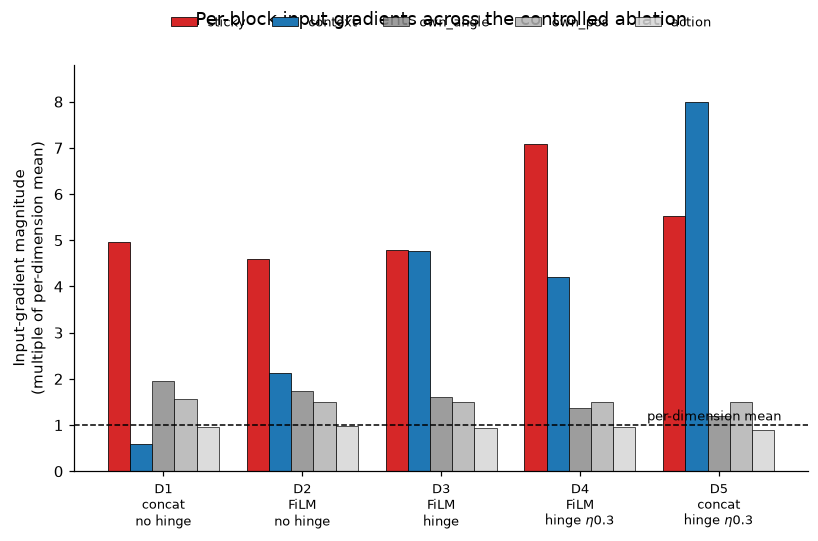

In [8]:
GRAD = {  # multiples of that variant's per-dimension mean
    "sticky":    [4.97, 4.60, 4.80, 7.08, 5.53],
    "context":   [0.59, 2.12, 4.77, 4.21, 7.99],
    "own_angle": [1.95, 1.73, 1.61, 1.37, 1.20],
    "own_pos":   [1.57, 1.49, 1.50, 1.49, 1.49],
    "action":    [0.96, 0.99, 0.93, 0.96, 0.89],
}

SUB = ["concat\nno hinge", "FiLM\nno hinge", "FiLM\nhinge",
       r"FiLM"+"\n"+r"hinge $\eta$0.3", r"concat"+"\n"+r"hinge $\eta$0.3"]
STY = {"sticky": ("tab:red", 1.0), "context": ("tab:blue", 1.0),
       "own_angle": ("0.55", 0.85), "own_pos": ("0.70", 0.85), "action": ("0.84", 0.85)}

x = np.arange(5); w = 0.16
fig, ax = plt.subplots(figsize=(8.6, 4.8))
for i, b in enumerate(GRAD):
    c, a = STY[b]
    ax.bar(x + (i - 2) * w, GRAD[b], w, label=b, color=c, alpha=a, edgecolor="k", lw=0.5)

ax.axhline(1.0, color="k", lw=1.0, ls="--")
ax.text(4.45, 1.10, "per-dimension mean", fontsize=8.5, ha="right")
ax.set_xticks(x, [f"D{i+1}\n{s}" for i, s in enumerate(SUB)], fontsize=8.5)
ax.set_ylabel("Input-gradient magnitude\n(multiple of per-dimension mean)")
ax.set_ylim(0, 8.8)
ax.legend(ncol=5, fontsize=8.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.15))
ax.set_title("Per-block input gradients across the controlled ablation", pad=26)
fig.savefig(f"{OUT}/fig_5_03_block_gradients.png")
plt.show()

C:\Users\u5749464\AppData\Local\Temp\ipykernel_20796\3024599354.py:2: RuntimeWarning: All-NaN slice encountered
  vmin = min(np.nanmin(m) for m in P.values())
C:\Users\u5749464\AppData\Local\Temp\ipykernel_20796\3024599354.py:3: RuntimeWarning: All-NaN slice encountered
  vmax = max(np.nanmax(m) for m in P.values())


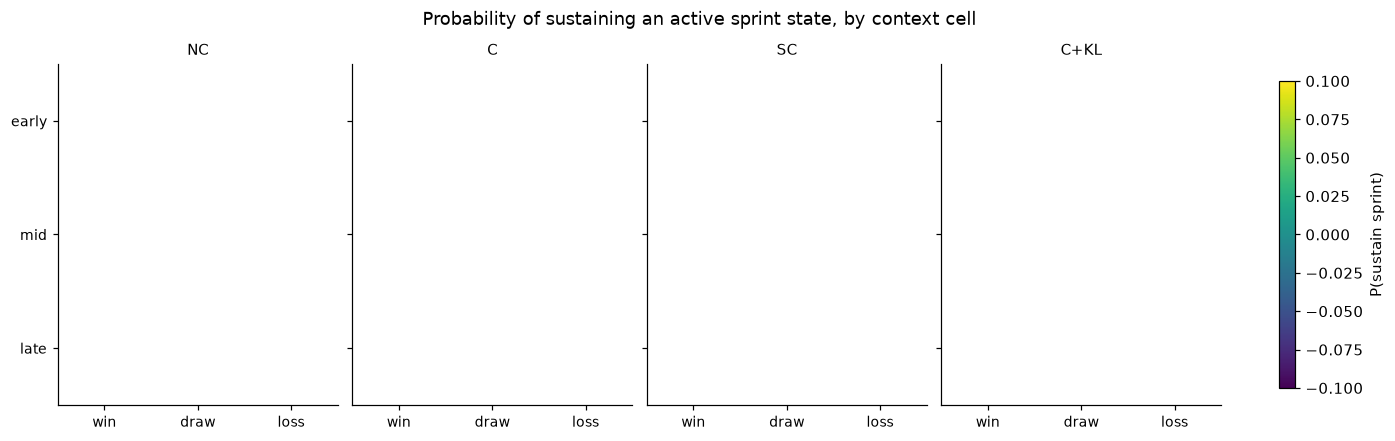

observed range nan - nan   (0-1 colourbar would flatten this)


In [9]:
P = {c: sustain_grid(rollouts[c]) for c in CONDS}
vmin = min(np.nanmin(m) for m in P.values())
vmax = max(np.nanmax(m) for m in P.values())
pad  = 0.15 * (vmax - vmin) if vmax > vmin else 0.001

fig, axs = plt.subplots(1, 4, figsize=(12.6, 3.6), constrained_layout=True)
for ax, c in zip(axs, CONDS):
    im = ax.imshow(P[c], cmap="viridis", vmin=vmin - pad, vmax=vmax + pad, aspect="auto")
    ax.set_xticks(range(3), ["win", "draw", "loss"], fontsize=9)
    ax.set_yticks(range(3), ["early", "mid", "late"] if c == "NC" else ["", "", ""], fontsize=9)
    ax.set_title(c, fontsize=10)
    for i in range(3):
        for j in range(3):
            v = P[c][i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=7.6,
                        color="white" if v < (vmin + vmax) / 2 else "black")

fig.colorbar(im, ax=axs, label="P(sustain sprint)", shrink=0.9)
fig.suptitle("Probability of sustaining an active sprint state, by context cell", y=1.07)
fig.savefig(f"{OUT}/fig_5_04_sustain_probability.png")
plt.show()

print(f"observed range {vmin:.4f} - {vmax:.4f}   (0-1 colourbar would flatten this)")

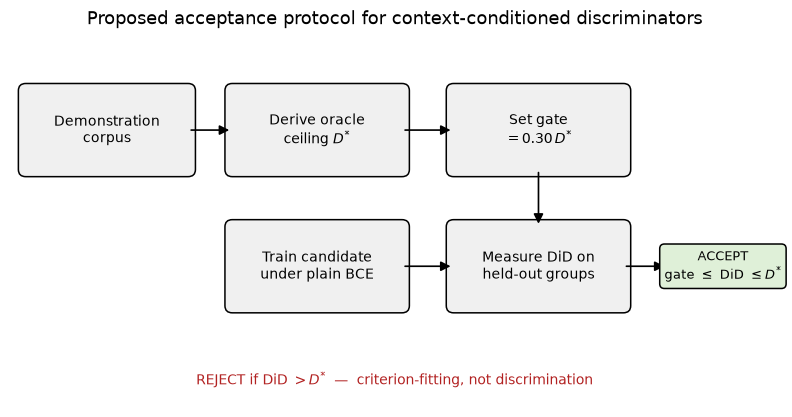

In [10]:
fig, ax = plt.subplots(figsize=(9.0, 4.4)); ax.axis("off")
ax.set_xlim(0, 10.4); ax.set_ylim(-0.6, 4.6)

def box(x, y, w, h, txt, fc="0.94"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.10",
                                fc=fc, ec="k", lw=1.0))
    ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=9)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=13, lw=1.1, color="k"))

box(0.2, 2.7, 2.2, 1.1, "Demonstration\ncorpus")
box(3.0, 2.7, 2.3, 1.1, "Derive oracle\nceiling $D^{*}$")
box(6.0, 2.7, 2.3, 1.1, "Set gate\n$=0.30\\,D^{*}$")
box(3.0, 0.8, 2.3, 1.1, "Train candidate\nunder plain BCE")
box(6.0, 0.8, 2.3, 1.1, "Measure DiD on\nheld-out groups")

arrow(2.4, 3.25, 3.0, 3.25)
arrow(5.3, 3.25, 6.0, 3.25)
arrow(7.15, 2.7, 7.15, 1.9)
arrow(5.3, 1.35, 6.0, 1.35)
arrow(8.3, 1.35, 8.9, 1.35)

ax.text(9.65, 1.35, "ACCEPT\ngate $\\leq$ DiD $\\leq D^{*}$", ha="center", va="center",
        fontsize=8.8, bbox=dict(boxstyle="round,pad=0.35", fc="#dff0d8", ec="k"))
ax.text(5.2, -0.30, "REJECT if DiD $> D^{*}$  —  criterion-fitting, not discrimination",
        ha="center", fontsize=9, color="firebrick")
ax.set_title("Proposed acceptance protocol for context-conditioned discriminators", pad=6)
fig.savefig(f"{OUT}/fig_6_03_acceptance_protocol.png")
plt.show()